# <span style="color:#c8b6ff">**Deciding with Numbers / Décider avec des chiffres**</span>

**Linear Regression: from raw data to weighted decisions**

> *Part of the **AI From Scratch** series - a progressive introduction to artificial intelligence for everyone.*

# <span style="color:#c8b6ff">**1. Welcome & Objectives**</span>

## Ce que tu vas apprendre ici

Ce notebook est le point de départ de toute la série. Pas de prérequis. On part de zéro (des tableaux de données) et on arrive à construire un modèle de régression linéaire qui fait des prédictions réelles.

À la fin de ce notebook, tu sauras :

- lire et comprendre un tableau de données
- distinguer les types de variables
- calculer des statistiques de base et comprendre ce qu'elles disent
- visualiser des relations entre variables
- comprendre ce qu'est un poids et pourquoi ça compte
- construire une régression linéaire à la main, puis avec scikit-learn
- appliquer tout ça sur un exemple concret : **les retards de vols**

### Comment utiliser ce notebook?

- **Lecture seule** : tu peux lire les cellules markdown et regarder les outputs sans rien exécuter
- **Run it yourself** : exécute les cellules dans l'ordre avec `Shift + Enter`
- **Modifie les valeurs** : les cellules marquées `# ✏️ ESSAIE DE MODIFIER` t'invitent à jouer avec les paramètres


# <span style="color:#c8b6ff">**2. The Intuition First: L'intuition avant tout**</span>

## Une **décision**, c'est quoi ?

Imagine que tu dois décider si tu prends ton parapluie ce matin. Tu regardes plusieurs choses :

- il y a des nuages → signal fort
- la météo annonce 80% de pluie → signal fort
- c'est la saison des pluies → signal moyen
- hier il faisait beau → signal faible

Tu **agrèges** ces signaux, tu leur donnes un poids mental, et tu décides.

**C'est exactement ce que fait une régression linéaire.**

Elle prend plusieurs informations (on les appelle des **features** ou **variables**), leur attribue un poids, les additionne, et produit une valeur de sortie.

$$y = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$

- $x_1, x_2, \dots$ → les informations d'entrée
- $w_1, w_2, \dots$ → les poids (ce que la machine apprend)
- $y$ → la valeur prédite
- $w_0$ → le biais (une valeur de base, même quand tout est à zéro)

## Vocabulaire clé

| Terme | Définition simple |
|-------|------------------|
| Feature / variable | Une information d'entrée (ex: température, heure) |
| Target / cible | Ce qu'on veut prédire (ex: retard en minutes) |
| Poids (weight) | L'importance donnée à chaque feature |
| Modèle | L'équation apprise à partir des données |
| Entraînement | Le processus d'apprentissage des poids |
| Prédiction | La valeur que le modèle produit pour un nouvel exemple |


# <span style="color:#c8b6ff">**3. The Math - Step by Step**</span>

## 3.1. Tableaux et données tabulaires

Toute l'IA commence par un tableau. Chaque **ligne** est un exemple. Chaque **colonne** est une information.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# Un tableau simple - 8 vols
data = {
    'retard_depart_min': [10, 45, 0, 120, 5, 80, 15, 60],
    'meteo_score':       [2,  8,  1,  9,  1,  7,  3,  6],   # 1=beau, 10=tempête
    'heure_depart':      [8, 18,  6, 21,  7, 17,  9, 20],   # heure du vol
    'nb_escales':        [0,  1,  0,  2,  0,  1,  0,  1],   # nombre d'escales
    'retard_arrivee_min':[12, 55,  2, 140,  8, 95, 18, 72]  # notre CIBLE/TARGET
}

df = pd.DataFrame(data)
print('Notre tableau de données :')
df

Notre tableau de données :


,retard_depart_min,meteo_score,heure_depart,nb_escales,retard_arrivee_min
0,10,2,8,0,12
1,45,8,18,1,55
2,0,1,6,0,2
3,120,9,21,2,140
4,5,1,7,0,8
5,80,7,17,1,95
6,15,3,9,0,18
7,60,6,20,1,72


**Ce qu'on lit dans ce tableau :**
- Chaque ligne = un vol
- Les colonnes de gauche = nos **features** (informations d'entrée)
- La dernière colonne = notre **target** (ce qu'on veut prédire)

La question qu'on pose à la machine : **<span style="color:#00b4d8">à partir du retard au départ, de la météo, de l'heure et du nombre d'escales - peut-on prédire le retard à l'arrivée ?</span>**

## 3.2. Variables et types

Toutes les colonnes ne se traitent de la même façon. Il y a deux grandes familles :

In [60]:
# Variables numériques → des nombres avec lesquels on peut calculer
print('Variables numériques :')
print(df[['retard_depart_min', 'meteo_score', 'heure_depart']].dtypes)

print()

# Variable catégorielle → des catégories (ex: type de compagnie)
compagnies = ['Air France', 'EasyJet', 'Air France', 'Ryanair',
              'Air France', 'EasyJet', 'Ryanair', 'Air France']
df['compagnie'] = compagnies
print('Variable catégorielle :')
print(df['compagnie'].value_counts())

Variables numériques :
retard_depart_min    int64
meteo_score          int64
heure_depart         int64
dtype: object

Variable catégorielle :
compagnie
Air France    4
EasyJet       2
Ryanair       2
Name: count, dtype: int64


**Pourquoi ça compte ?**

- Une variable **numérique** : on peut directement la multiplier par un poids
- Une variable **catégorielle** : il faut d'abord la transformer en nombres (on appelle ça l'encodage)

Pour l'instant on travaille avec les numériques (c'est plus simple pour commencer).

## 3.3. Moyenne, médiane, écart-type

Avant de modéliser quoi que ce soit, on regarde les données. Trois indicateurs suffisent pour commencer :

Moyenne   : 50.2 min  → le retard "typique"
Médiane   : 36.5 min  → la valeur du milieu (moins sensible aux extrêmes)
Écart-type: 49.5 min  → à quel point les retards varient
Min / Max : 2 / 140 min


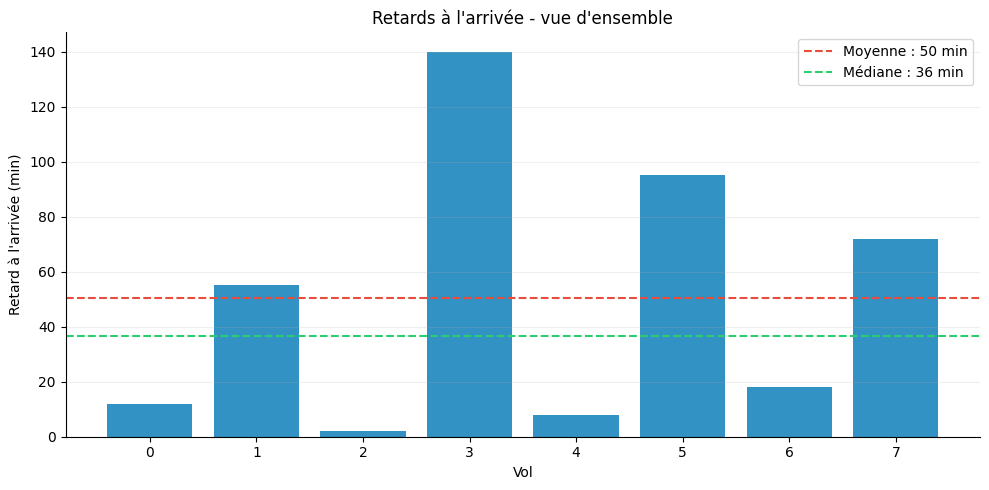

In [61]:
retards = df['retard_arrivee_min']

print(f'Moyenne   : {retards.mean():.1f} min  → le retard "typique"')
print(f'Médiane   : {retards.median():.1f} min  → la valeur du milieu (moins sensible aux extrêmes)')
print(f'Écart-type: {retards.std():.1f} min  → à quel point les retards varient')
print(f'Min / Max : {retards.min()} / {retards.max()} min')

# Visualisation
fig, ax = plt.subplots()
ax.bar(range(len(retards)), retards, color='#0077b6', alpha=0.8)
ax.axhline(retards.mean(), color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Moyenne : {retards.mean():.0f} min')
ax.axhline(retards.median(), color='#2ECC71', linestyle='--', linewidth=1.5, label=f'Médiane : {retards.median():.0f} min')
ax.set_xlabel('Vol')
ax.set_ylabel('Retard à l\'arrivée (min)')
ax.set_title('Retards à l\'arrivée - vue d\'ensemble')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

**Ce qu'on retient :**
- La **moyenne** est sensible aux valeurs extrêmes - un vol avec 4h de retard tire la moyenne vers le haut
- La **médiane** est plus robuste - elle dit juste "la moitié des vols sont en dessous de cette valeur"
- L'**écart-type** mesure la dispersion - un écart-type élevé = les retards sont très variables

## 3.4. Corrélation et visualisation

La corrélation mesure à quel point deux variables bougent ensemble.

- **+1** : quand l'une monte, l'autre monte aussi (parfaitement)
- **-1** : quand l'une monte, l'autre descend (parfaitement)
- **0** : aucune relation

C'est la première question à poser : **<span style="color:#00b4d8">mes features ont-elles un lien avec ma target ?</span>**

Corrélation avec le retard à l'arrivée :
retard_depart_min    1.00
nb_escales           0.97
meteo_score          0.91
heure_depart         0.91
Name: retard_arrivee_min, dtype: float64


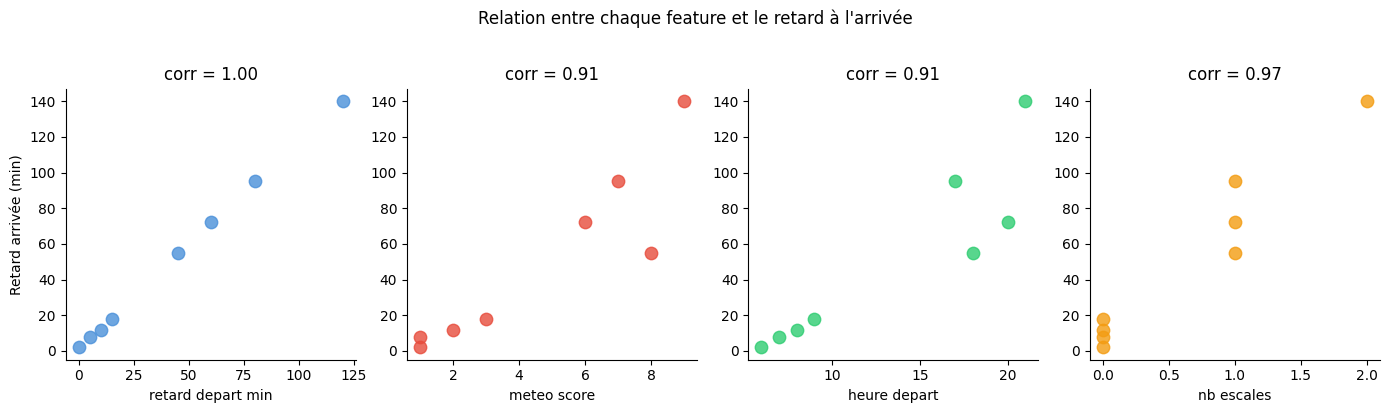

In [62]:
features = ['retard_depart_min', 'meteo_score', 'heure_depart', 'nb_escales']

print('Corrélation avec le retard à l\'arrivée :')
correlations = df[features + ['retard_arrivee_min']].corr()['retard_arrivee_min'].drop('retard_arrivee_min')
print(correlations.sort_values(ascending=False).round(2))

# Scatter plots
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colors = ['#4A90D9', '#E74C3C', '#2ECC71', '#F39C12']

for i, (feat, color) in enumerate(zip(features, colors)):
    axes[i].scatter(df[feat], df['retard_arrivee_min'], color=color, alpha=0.8, s=80)
    axes[i].set_xlabel(feat.replace('_', ' '))
    axes[i].set_ylabel('Retard arrivée (min)' if i == 0 else '')
    corr_val = correlations[feat]
    axes[i].set_title(f'corr = {corr_val:.2f}')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Relation entre chaque feature et le retard à l\'arrivée', y=1.02)
plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- Le retard au départ a une forte corrélation avec le retard à l'arrivée → **feature très utile**
- La météo aussi, logique
- L'heure de départ a peu d'effet ici, dans **NOTRE** cas (peut être oui dans s'autres contextes)

> Une bonne feature, c'est une variable qui **varie avec la target**. Si la corrélation est proche de 0, la feature n'apporte pas grand chose au modèle.

## 3.5. La notion de poids

Maintenant qu'on sait quelles features comptent, on peut introduire l'idée de **poids**.

Un poids, c'est simplement : **<span style="color:#00b4d8">combien cette feature influence la prédiction ?</span>**

Concrètement, toutes les variables n’ont pas la même importance.
Certaines ont un effet très fort sur le résultat, tandis que d’autres jouent un rôle plus secondaire. Le poids sert justement à représenter cette différence : **plus le poids est élevé, plus la variable a d’impact sur la prédiction**.

Il faut aussi ajouter un élément un peu particulier : **le biais**.

**Le biais, on peut le voir comme le retard "de base" qu’on prévoit même avant de regarder les détails du vol.**

Dans l'exemple ci-dessous, il vaut **0,5 minute**. Cela veut dire que, même sans information particulière sur la météo, l’heure de départ ou le nombre d’escales, on considère qu’il peut déjà exister un tout petit retard habituel. En pratique, c’est un peu comme dire : <span style="color:#00b4d8">*"même quand tout semble normal, un vol n’est pas forcément parfaitement à l’heure"*</span>.

Ensuite, les autres éléments viennent **ajouter** ou parfois **retirer** du retard à cette base. Toujours dans cet exemple :

* le **retard au départ** ajoute **4,5 minutes** ;
* la **météo** ajoute **1,5 minute** ;
* l’**heure de départ** ajoute seulement **0,3 minute** ;
* le **nombre d’escales** ajoute **20 minutes**.
* <span style="color:#00b4d8">prediction = **0,5 + 4,5 + 1,5 + 0,3 + 20 = 26,8**</span>.

Au final, on part donc d’un **petit retard de base de 0,5 minute**, puis on ajoute l’effet de chaque situation observée, ce qui donne **26,8 minutes** de retard prédit.

In [63]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Coefficients du modèle
biais = widgets.FloatSlider(
    value=0.5, min=-10, max=10, step=0.1,
    description="biais", continuous_update=False
)
coef_retard_depart = widgets.FloatSlider(
    value=0.9, min=-2, max=2, step=0.1,
    description="coef retard", continuous_update=False
)
coef_meteo = widgets.FloatSlider(
    value=0.5, min=-5, max=5, step=0.1,
    description="coef météo", continuous_update=False
)
coef_heure_depart = widgets.FloatSlider(
    value=0.02, min=-1, max=1, step=0.1,
    description="coef heure", continuous_update=False
)
coef_escales = widgets.FloatSlider(
    value=20.0, min=0, max=20, step=0.5,
    description="coef escales", continuous_update=False
)

# Variables d'entrée
retard_depart = widgets.IntSlider(
    value=5, min=0, max=300, step=5,
    description="retard départ", continuous_update=False
)
meteo = widgets.IntSlider(
    value=3, min=0, max=10, step=1,
    description="météo", continuous_update=False
)
heure_depart = widgets.IntSlider(
    value=17, min=0, max=23, step=1,
    description="heure départ", continuous_update=False
)
escales = widgets.IntSlider(
    value=1, min=0, max=3, step=1,
    description="escales", continuous_update=False
)

bouton = widgets.Button(description="PREDIRE")
sortie = widgets.Output()

def calculer_prediction(_):
    prediction = (
        biais.value
        + coef_retard_depart.value * retard_depart.value
        + coef_meteo.value * meteo.value
        + coef_heure_depart.value * heure_depart.value
        + coef_escales.value * escales.value
    )

    with sortie:
        clear_output()
        print("calcul détaillé :")
        print(f"biais                : {biais.value:.1f}")
        print(f"retard départ        : {coef_retard_depart.value * retard_depart.value:.1f}")
        print(f"météo                : {coef_meteo.value * meteo.value:.1f}")
        print(f"heure départ         : {coef_heure_depart.value * heure_depart.value:.1f}")
        print(f"nombre d'escales     : {coef_escales.value * escales.value:.1f}")
        print("-" * 30)
        print(f"retard prédit        : {prediction:.1f} min")

bouton.on_click(calculer_prediction)

# Colonne gauche : coefficients
colonne_gauche = widgets.VBox([
    widgets.HTML("<b>coefficients</b>"),
    biais,
    coef_retard_depart,
    coef_meteo,
    coef_heure_depart,
    coef_escales
])

# Colonne droite : variables
colonne_droite = widgets.VBox([
    widgets.HTML("<b>variables</b>"),
    retard_depart,
    meteo,
    heure_depart,
    escales
])

# 2 colonnes côte à côte
colonnes = widgets.HBox([
    colonne_gauche,
    colonne_droite
])

# Interface finale
interface = widgets.VBox([
    colonnes,
    bouton,
    sortie
])

display(interface)

**Ce second exemple montre qu’en changeant uniquement les poids, on change aussi la lecture de la situation.**
Le vol a toujours **5 minutes de retard au départ**, une **météo de 3/10** (assez bonne), un départ à **17h** et **1 escale**, mais ici on estime que ces informations n’ont pas toutes la même importance. Le modèle accorde peu de place au retard de départ, presque aucune au biais, un peu plus à la météo, et beaucoup au nombre d’escales. Le résultat final, **14,1 minutes**, reflète donc cette nouvelle répartition de l’importance entre les facteurs.

In [64]:
# Coefficients du modèle
biais = widgets.FloatSlider(
    value=0.01, min=-10, max=10, step=0.1,
    description="biais", continuous_update=False
)
coef_retard_depart = widgets.FloatSlider(
    value=0.2, min=-2, max=2, step=0.1,
    description="coef retard", continuous_update=False
)
coef_meteo = widgets.FloatSlider(
    value=0.9, min=-5, max=5, step=0.1,
    description="coef météo", continuous_update=False
)
coef_heure_depart = widgets.FloatSlider(
    value=0.02, min=-1, max=1, step=0.1,
    description="coef heure", continuous_update=False
)
coef_escales = widgets.FloatSlider(
    value=10.0, min=0, max=20, step=0.5,
    description="coef escales", continuous_update=False
)

# Variables d'entrée
retard_depart = widgets.IntSlider(
    value=5, min=0, max=300, step=5,
    description="retard départ", continuous_update=False
)
meteo = widgets.IntSlider(
    value=3, min=0, max=10, step=1,
    description="météo", continuous_update=False
)
heure_depart = widgets.IntSlider(
    value=17, min=0, max=23, step=1,
    description="heure départ", continuous_update=False
)
escales = widgets.IntSlider(
    value=1, min=0, max=3, step=1,
    description="escales", continuous_update=False
)

bouton = widgets.Button(description="PREDIRE")
sortie = widgets.Output()

def calculer_prediction(_):
    prediction = (
        biais.value
        + coef_retard_depart.value * retard_depart.value
        + coef_meteo.value * meteo.value
        + coef_heure_depart.value * heure_depart.value
        + coef_escales.value * escales.value
    )

    with sortie:
        clear_output()
        print("calcul détaillé :")
        print(f"biais                : {biais.value:.1f}")
        print(f"retard départ        : {coef_retard_depart.value * retard_depart.value:.1f}")
        print(f"météo                : {coef_meteo.value * meteo.value:.1f}")
        print(f"heure départ         : {coef_heure_depart.value * heure_depart.value:.1f}")
        print(f"nombre d'escales     : {coef_escales.value * escales.value:.1f}")
        print("-" * 30)
        print(f"retard prédit        : {prediction:.1f} min")

bouton.on_click(calculer_prediction)

# Colonne gauche : coefficients
colonne_gauche = widgets.VBox([
    widgets.HTML("<b>coefficients</b>"),
    biais,
    coef_retard_depart,
    coef_meteo,
    coef_heure_depart,
    coef_escales
])

# Colonne droite : variables
colonne_droite = widgets.VBox([
    widgets.HTML("<b>variables</b>"),
    retard_depart,
    meteo,
    heure_depart,
    escales
])

# 2 colonnes côte à côte
colonnes = widgets.HBox([
    colonne_gauche,
    colonne_droite
])

# Interface finale
interface = widgets.VBox([
    colonnes,
    bouton,
    sortie
])

display(interface)

**Ce qu'on vient de faire à la main**, c'est exactement ce que fait la régression linéaire, sauf qu'elle trouve les poids <span style="color:#00b4d8">**automatiquement**</span> à partir des données, sans qu'on ait besoin de les deviner.

**Ce second exemple montre qu’en changeant uniquement les poids, on change aussi la lecture de la situation.**
Le vol a toujours **5 minutes de retard au départ**, une **météo de 3/10** (assez bonne), un départ à **17h** et **1 escale**, mais ici on estime que ces informations n’ont pas toutes la même importance. Le modèle accorde peu de place au retard de départ, presque aucune au biais, un peu plus à la météo, et beaucoup au nombre d’escales. Le résultat final, **14,1 minutes**, reflète donc cette nouvelle répartition de l’importance entre les facteurs.

## 3.6. Multiplication matricielle (Pour aller plus loin)

Quand on a plusieurs exemples à la fois, on ne fait pas le calcul un par un. On utilise des **matrices** (des tableaux de nombres) pour tout calculer en une seule opération.

L'idée est simple : une matrice X (nos données) multipliée par un vecteur w (nos poids) donne directement toutes les prédictions.

In [65]:
# Nos données sous forme de matrice numpy
X = df[['retard_depart_min', 'meteo_score', 'heure_depart', 'nb_escales']].values

print("Données dataframe :")
display(df[['retard_depart_min', 'meteo_score', 'heure_depart', 'nb_escales']])

print(f"Données (matrice numpy) : {X.shape[0]} lignes, {X.shape[1]} colonnes\n{X}")
# Numpy est une bibliothèque Python pour le calcul scientifique

# Nos poids (on les choisit manuellement pour l'instant)
w = np.array([0.9, 3.5, 0.2, 8.0])
w0 = 2.0  # biais

W = np.array([w0] + w.tolist())
print(f"\nMatrice des poids utilisés dans cet exemple (ce sont des coefficients choisis manuellement) :\n{W}")

print()

# Une seule ligne pour calculer les prédictions sur TOUS les exemples
predictions_manuelles = X @ w + w0

print()
print(f"Prédictions manuelles :\n{predictions_manuelles}")
print()

# Comparaison
print('Vol | Prédit | Réel')
print('────────────────────')
for i, (pred, reel) in enumerate(zip(predictions_manuelles, df['retard_arrivee_min'])):
    diff = pred - reel
    print(f'  {i+1} | {pred:6.1f} | {reel:4d}  (écart: {diff:+.1f})')

Données dataframe :


,retard_depart_min,meteo_score,heure_depart,nb_escales
0,10,2,8,0
1,45,8,18,1
2,0,1,6,0
3,120,9,21,2
4,5,1,7,0
5,80,7,17,1
6,15,3,9,0
7,60,6,20,1


Données (matrice numpy) : 8 lignes, 4 colonnes
[[ 10   2   8   0]
 [ 45   8  18   1]
 [  0   1   6   0]
 [120   9  21   2]
 [  5   1   7   0]
 [ 80   7  17   1]
 [ 15   3   9   0]
 [ 60   6  20   1]]

Matrice des poids utilisés dans cet exemple (ce sont des coefficients choisis manuellement) :
[2.  0.9 3.5 0.2 8. ]


Prédictions manuelles :
[ 19.6  82.1   6.7 161.7  11.4 109.9  27.8  89. ]

Vol | Prédit | Réel
────────────────────
  1 |   19.6 |   12  (écart: +7.6)
  2 |   82.1 |   55  (écart: +27.1)
  3 |    6.7 |    2  (écart: +4.7)
  4 |  161.7 |  140  (écart: +21.7)
  5 |   11.4 |    8  (écart: +3.4)
  6 |  109.9 |   95  (écart: +14.9)
  7 |   27.8 |   18  (écart: +9.8)
  8 |   89.0 |   72  (écart: +17.0)


**Ce qu'on retient :**
- `X @ w` c'est juste "pour chaque ligne, multiplie chaque valeur par son poids et additionne"
- Le `@` en Python, c'est l'opérateur de multiplication matricielle
- Les écarts entre prédit et réel, c'est l'<span style="color:#00b4d8">**erreur**</span>, et c'est exactement cette erreur que **la machine va apprendre à minimiser**


# <span style="color:#c8b6ff">**4. Building it Manually - Trouver les poids à partir des données**</span>

**<h3>Comment la machine apprend à agréger les informations ?</h3>**

Jusqu’ici, on a choisi les poids à la main pour comprendre leur rôle.

Mais en pratique, une machine ne choisit pas ces poids “au feeling”.  
<span style="color:#00b4d8">Elle apprend, à partir d’exemples passés, comment combiner plusieurs informations pour produire une bonne réponse.</span>

Dans notre cas, chaque vol est décrit par plusieurs nombres :

- le retard au départ,
- la météo,
- l’heure de départ,
- le nombre d’escales.

Le but n’est pas que la machine “comprenne” le vol comme un humain.  
<span style="color:#00b4d8">Le but est plus simple : trouver la bonne façon de mélanger ces informations pour obtenir un retard prédit proche de la réalité.</span>

Autrement dit, elle cherche :

- quelles informations comptent le plus,
- lesquelles comptent moins,
- et comment les agréger pour transformer plusieurs nombres en une seule décision.

C’est exactement l’idée centrale de la régression linéaire :  
**<span style="color:#00b4d8">prendre plusieurs signaux, leur attribuer un poids, puis les additionner pour produire une prédiction.</span>**

Dans le code ci-dessous, on donne au programme des vols passés avec leurs caractéristiques et leur vrai retard à l’arrivée.  
<span style="color:#00b4d8">Le programme cherche alors automatiquement la combinaison de poids qui reproduit le mieux ce qu’on a observé.</span>

In [66]:
# 1. On récupère les informations des vols (les variables explicatives, les informations qu'on veut agréger pour décider)
X_raw = df[['retard_depart_min', 'meteo_score', 'heure_depart', 'nb_escales']].values
y = df['retard_arrivee_min'].values.astype(float)

# 2. On ajoute une colonne de 1 (paramètre de biais) pour permettre au modèle d'avoir un biais
X_b = np.c_[np.ones(len(X_raw)), X_raw]

# 3. On calcule automatiquement les meilleurs poids à partir des données passées
w_optimal = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y # Équation de la régression linéaire

print("Poids appris automatiquement :")
noms = ['Biais (w0)', 'Retard départ', 'Météo score', 'Heure départ', 'Nb escales']
for nom, w in zip(noms, w_optimal):
    print(f'  {nom:<20} : {w:+.3f}')

# 4. On vérifie si les prédictions sont proches de la réalité
y_pred = X_b @ w_optimal
erreur_moyenne = np.mean(np.abs(y_pred - y))
print(f'\nErreur moyenne : {erreur_moyenne:.1f} min')

Poids appris automatiquement :
  Biais (w0)           : +0.459
  Retard départ        : +1.122
  Météo score          : -0.068
  Heure départ         : +0.184
  Nb escales           : +1.085

Erreur moyenne : 0.6 min


### Ce qu’il faut retenir de ce calcul

Le programme vient d’apprendre **<span style="color:#00b4d8">comment agréger les informations</span>**.

Chaque poids répond à une question très simple :  
**<span style="color:#00b4d8">quand cette information change, à quel point cela fait-elle bouger la prédiction ?</span>**

Par exemple :

- si le poids du retard au départ est élevé, cela veut dire que cette information pèse beaucoup dans le résultat final ;
- si le poids de la météo est plus faible, cela veut dire qu’elle influence moins la prédiction ;
- le biais représente un <span style="color:#00b4d8">niveau de départ</span>, avant même d’ajouter les autres informations.

Le programme a trouvé automatiquement les poids suivants :

* **biais** : 0,459
* **retard départ** : 1,122
* **météo** : -0,068
* **heure départ** : 0,184
* **nombre d’escales** : 1,085

Cela veut dire que, dans nos données :

* le **retard au départ** a un effet important sur le retard final ;
* le **nombre d’escales** compte aussi beaucoup ;
* l’**heure de départ** a un effet plus modéré ;
* la **météo** a ici un effet très faible, et légèrement négatif dans cet exemple précis.

L’idée importante n’est donc pas la formule en elle-même.  
<span style="color:#00b4d8">L’idée importante, c’est de voir que la machine a appris une manière de résumer plusieurs indices en une seule valeur utile.</span>

Autrement dit, elle :

- récupère de l’information,
- la transforme en nombres,
- lui donne une importance,
- puis la synthétise en une prédiction finale.

**<span style="color:#00b4d8">C’est ça, au fond, la logique de base de l’IA dans cet exemple : agréger des nombres pour décider.</span>**

### Cependant

Il ne faut pas forcément lire ces nombres comme des vérités absolues sur tous les vols du monde.
Il faut surtout les comprendre comme : **ce sont les réglages que la machine a trouvés pour mieux coller aux données qu’on lui a montrées**.

Enfin, l’**erreur moyenne de 0,6 minute** indique que, sur les vols utilisés ici, les prédictions sont en moyenne très proches de la réalité.
Autrement dit, le modèle s’en sort bien sur cet exemple.

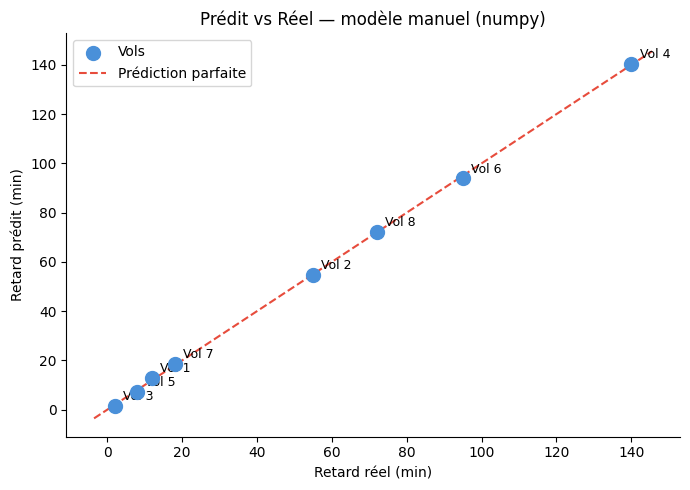

In [67]:
# Visualisation : prédit vs réel
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y, y_pred, color='#4A90D9', s=100, zorder=5, label='Vols')

lims = [min(y.min(), y_pred.min()) - 5, max(y.max(), y_pred.max()) + 5]
ax.plot(lims, lims, '--', color='#E74C3C', linewidth=1.5, label='Prédiction parfaite')

for i, (reel, pred) in enumerate(zip(y, y_pred)):
    ax.annotate(f'Vol {i+1}', (reel, pred), textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Retard réel (min)')
ax.set_ylabel('Retard prédit (min)')
ax.set_title('Prédit vs Réel — modèle manuel (numpy)')
ax.legend()
plt.tight_layout()
plt.show()

### Comment lire le graphique ?

Chaque point représente un vol.

- sur l’axe horizontal : le <span style="color:#00b4d8">retard réel</span> ;
- sur l’axe vertical : le <span style="color:#00b4d8">retard prédit</span>.

La ligne rouge représente le cas idéal :  
<span style="color:#00b4d8">si un point tombe sur cette ligne, cela veut dire que la prédiction est parfaite.</span>

Ici, on voit que les points sont très proches de cette ligne.  
Cela signifie que le modèle a bien appris à combiner les informations disponibles pour retrouver des valeurs proches de la réalité.

Autrement dit, les informations ont été :

- bien récupérées,
- bien pondérées,
- puis bien synthétisées.

<span style="color:#00b4d8">Ce graphique montre donc visuellement que l’agrégation fonctionne : la machine transforme plusieurs nombres en une prédiction cohérente.</span>

# <span style="color:#c8b6ff">**5. Using the Real Tool - Avec scikit-learn**</span>

En pratique, on n'écrit pas la formule des moindres carrés à la main. On utilise `scikit-learn` qui fait tout ça de façon optimisée et fiable.

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_sk = df[['retard_depart_min', 'meteo_score', 'heure_depart', 'nb_escales']]
y_sk = df['retard_arrivee_min']

model = LinearRegression()
model.fit(X_sk, y_sk)

print('Poids appris par scikit-learn :')
print(f'  {"Biais (intercept)":<25} : {model.intercept_:+.3f}')
for nom, coef in zip(X_sk.columns, model.coef_):
    print(f'  {nom:<25} : {coef:+.3f}')

y_pred_sk = model.predict(X_sk)
print(f'\nMAE  (erreur moyenne absolue) : {mean_absolute_error(y_sk, y_pred_sk):.1f} min')
print(f'R²   (qualité globale 0→1)    : {r2_score(y_sk, y_pred_sk):.3f}')

Poids appris par scikit-learn :
  Biais (intercept)         : +0.459
  retard_depart_min         : +1.122
  meteo_score               : -0.068
  heure_depart              : +0.184
  nb_escales                : +1.085

MAE  (erreur moyenne absolue) : 0.6 min
R²   (qualité globale 0→1)    : 1.000


**Comment lire ces résultats :**

- **MAE** (Mean Absolute Error) : en moyenne, notre modèle se trompe de X minutes
- **R²** : 0 = le modèle ne sert à rien / 1 = prédictions parfaites. Plus de 0.75 = très bon.

> <span style="color:#00b4d8">Les poids de sklearn et notre calcul numpy sont quasi-identiques et c'est normal : **ils résolvent le même problème.**</span>

### Tester le modèle sur un nouveau vol

Jusqu’ici, on a surtout regardé comment le modèle apprend à partir de vols passés.  
Maintenant, on peut l’utiliser sur <span style="color:#00b4d8">un nouveau cas</span>.

L’idée reste la même :
- on donne au modèle plusieurs informations sur le vol ;
- il combine ces nombres ;
- puis il produit une <span style="color:#00b4d8">prédiction de retard</span>.

Le widget ci-dessous permet de modifier facilement les caractéristiques d’un vol et d’observer comment la prédiction évolue.

In [69]:
# Variables du nouveau vol
retard_depart = widgets.IntSlider(
    value=25, min=0, max=300, step=5,
    description="retard", continuous_update=False
)

meteo_score = widgets.IntSlider(
    value=7, min=0, max=10, step=1,
    description="météo", continuous_update=False
)

heure_depart = widgets.IntSlider(
    value=19, min=0, max=23, step=1,
    description="heure", continuous_update=False
)

nb_escales = widgets.IntSlider(
    value=1, min=0, max=3, step=1,
    description="escales", continuous_update=False
)

bouton = widgets.Button(description="prédire")
sortie = widgets.Output()

def predire(_):
    nouveau_vol = pd.DataFrame([{
        'retard_depart_min': retard_depart.value,
        'meteo_score': meteo_score.value,
        'heure_depart': heure_depart.value,
        'nb_escales': nb_escales.value
    }])

    retard_predit = model.predict(nouveau_vol)[0]

    with sortie:
        clear_output()
        print("nouveau vol :")
        print(f"- retard au départ : {retard_depart.value} min")
        print(f"- météo           : {meteo_score.value}/10")
        print(f"- heure départ    : {heure_depart.value}h")
        print(f"- escales         : {nb_escales.value}")
        print("-" * 30)
        print("Le modèle combine les informations du vol pour produire une estimation.")
        print(f"Retard prédit à l'arrivée : {retard_predit:.1f} min")

bouton.on_click(predire)

colonne_gauche = widgets.VBox([
    widgets.HTML("<b>Entrez les informations d'un nouveau vol</b>"),
    retard_depart,
    meteo_score,
    heure_depart,
    nb_escales
])

interface = widgets.VBox([
    colonne_gauche,
    bouton,
    sortie
])

display(interface)

Ce petit test permet de voir très concrètement ce que fait le modèle :  
<span style="color:#00b4d8">il ne “comprend” pas le vol comme un humain, il agrège simplement plusieurs nombres pour produire une estimation.</span>

<span style="color:red">Quand on change le retard au départ, la météo, l’heure ou le nombre d’escales, la prédiction change aussi.  
**Cela montre bien que la décision finale dépend de la combinaison de plusieurs informations, et pas d’un seul facteur isolé.**</span>

# <span style="color:#c8b6ff">**6. A Real-World Example - Retards de vols en 2026**</span>

Jusqu’ici, on a vu l’idée générale :  
**<span style="color:#00b4d8">une IA agrège plusieurs informations pour produire une décision.</span>**

On passe maintenant à un exemple plus réaliste, avec un dataset de <span style="color:#00b4d8">50 000 vols</span> et <span style="color:#00b4d8">25 variables</span> de types différents.

L’objectif n’est pas seulement d’entraîner un modèle.

L’objectif est de montrer que :
- <span style="color:#00b4d8">la qualité de la prédiction dépend de la qualité de l’information fournie</span> ;
- les choix de préparation des données changent réellement le résultat ;
- une IA “décide” d’autant mieux que le contexte qu’on lui donne est propre, cohérent et utile.

Autrement dit, avant même de parler de modèle, il faut d’abord <span style="color:#00b4d8">fabriquer un bon décideur</span> :  
un système qui consomme des informations, les agrège correctement, puis produit une décision fiable.

In [70]:
import numpy as np
import pandas as pd

from IPython.display import display, clear_output
import ipywidgets as widgets

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [71]:
# On charge le fichier de données sur les 50000 vols
df_real = pd.read_csv('dataset_vols.csv')

print(f"Dataset final : {len(df_real):,} vols")
print(f"Variables explicatives : {df_real.shape[1] - 1}")
df_real.head()

Dataset final : 50,000 vols
Variables explicatives : 25


,retard_depart_min,meteo_score,heure_depart,nb_escales,charge_reseau,distance_km,vent_kmh,precipitation_mm,temperature_c,congestion_aeroport,...,compagnie,aeroport_depart,aeroport_arrivee,type_avion,jour_semaine,vol_international,hub_depart,greve_sol,changement_equipage,retard_arrivee_min
0,17.2,6.0,6,1,0.981,7494,36.1,NaN,19.5,0.435,...,SkyJet,ORY,MRS,B787,Ven,1,1,0,0,111.5
1,7.7,9.0,11,1,0.378,1160,10.4,1.1,6.6,0.256,...,HexaWings,CDG,CDG,E190,Ven,1,1,0,0,46.9
2,2.2,4.0,14,0,0.799,914,10.1,0.1,11.2,0.283,...,HexaWings,NCE,BOD,A320,Jeu,0,0,0,0,24.9
3,21.4,4.0,22,0,NaN,1954,32.2,4.4,27.8,0.228,...,BlueConnect,LIL,ORY,A330,Ven,0,0,0,0,63.8
4,72.0,6.0,9,0,0.978,1370,46.9,1.6,13.7,0.611,...,NovaAir,ORY,MRS,B737,Mer,1,1,0,0,118.1


On va maintenant explorer nos informations

In [72]:
target_col = 'retard_arrivee_min'

def eda_protocol(df, target):
    print("=== Vue d'ensemble ===")
    print(f"Lignes : {len(df):,}")
    print(f"Colonnes : {df.shape[1]}")
    print(f"Doublons exacts : {df.duplicated().sum():,}")
    print()

    print("=== Types de variables ===")
    print(df.info())

    print("=== Valeurs manquantes (%) ===")
    missing = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
    display(missing[missing > 0].to_frame('missing_%'))

    print("=== Statistiques de la cible ===")
    display(df[target].describe().round(2).to_frame().T)

    print("=== Cardinalité des variables catégorielles ===")
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if cat_cols:
        cardinality = pd.Series({c: df[c].nunique(dropna=True) for c in cat_cols}).sort_values(ascending=False)
        display(cardinality.to_frame('n_modalites'))

    print("=== Corrélations numériques avec la cible ===")
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target]
    corr = df[num_cols + [target]].corr(numeric_only=True)[target].drop(target).sort_values(key=np.abs, ascending=False)
    display(corr.round(3).to_frame('corr_target'))

eda_protocol(df_real, target_col)

=== Vue d'ensemble ===
Lignes : 50,000
Colonnes : 26
Doublons exacts : 1,000

=== Types de variables ===
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   retard_depart_min       50000 non-null  float64
 1   meteo_score             47994 non-null  float64
 2   heure_depart            50000 non-null  int64  
 3   nb_escales              50000 non-null  int64  
 4   charge_reseau           48502 non-null  float64
 5   distance_km             50000 non-null  int64  
 6   vent_kmh                46991 non-null  float64
 7   precipitation_mm        46993 non-null  float64
 8   temperature_c           48493 non-null  float64
 9   congestion_aeroport     47999 non-null  float64
 10  experience_captain_ans  48497 non-null  float64
 11  maintenance_score       47494 non-null  float64
 12  ponctualite_route_hist  48001 non-null  float64
 1

,missing_%
vent_kmh,6.02
precipitation_mm,6.01
maintenance_score,5.01
meteo_score,4.01
congestion_aeroport,4.00
ponctualite_route_hist,4.00
temperature_c,3.01
experience_captain_ans,3.01
charge_reseau,3.00
type_avion,2.00


=== Statistiques de la cible ===


,count,mean,std,min,25%,50%,75%,max
retard_arrivee_min,50000.0,58.91,26.17,0.0,40.4,55.9,74.1,296.5


=== Cardinalité des variables catégorielles ===


/tmp/ipykernel_30496/390493851.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


,n_modalites
aeroport_depart,8
aeroport_arrivee,8
jour_semaine,7
compagnie,6
type_avion,5


=== Corrélations numériques avec la cible ===


,corr_target
retard_depart_min,0.662
distance_km,0.432
vol_international,0.391
nb_escales,0.301
meteo_score,0.282
greve_sol,0.148
congestion_aeroport,0.134
charge_reseau,0.133
experience_captain_ans,-0.120
rotations_24h,0.115


### Lecture rapide de l’EDA

Ce premier aperçu montre surtout une chose : <span style="color:#00b4d8">avant même d’entraîner/utiliser une IA, il faut regarder la qualité des informations qu’on va lui donner.</span>  
Ici, on a un dataset assez riche, avec <span style="color:#00b4d8">50 000 vols</span>, des variables numériques, binaires et catégorielles, donc plusieurs types de signaux à agréger. On voit aussi qu’il y a <span style="color:#00b4d8">des valeurs manquantes</span> sur certaines colonnes et <span style="color:#00b4d8">1 000 doublons</span>, ce qui veut dire que les données ne sont pas prêtes “telles quelles”. Enfin, les corrélations donnent déjà une intuition utile : certains facteurs, comme le <span style="color:#00b4d8">retard au départ</span>, la <span style="color:#00b4d8">distance</span> ou le <span style="color:#00b4d8">nombre d’escales</span>, semblent plus liés au retard final que d’autres. <span style="color:#00b4d8">Autrement dit, cette étape sert à vérifier ce qu’on a entre les mains avant de fabriquer notre décideur.</span>

In [73]:
target_col = 'retard_arrivee_min'

all_features = [c for c in df_real.columns if c != target_col]

categorical_cols = ['compagnie', 'aeroport_depart', 'aeroport_arrivee', 'type_avion', 'jour_semaine']
binary_cols = ['vol_international', 'hub_depart', 'greve_sol', 'changement_equipage']
numeric_cols = [
    'retard_depart_min', 'meteo_score', 'heure_depart', 'nb_escales', 'charge_reseau',
    'distance_km', 'vent_kmh', 'precipitation_mm', 'temperature_c', 'congestion_aeroport',
    'experience_captain_ans', 'maintenance_score', 'ponctualite_route_hist',
    'age_avion_ans', 'rotations_24h', 'passagers'
]

def build_experiment(df, strategy='propre'):
    data = df.copy()

    decisions = []

    # ------------------------------------
    # STRATEGIE 1 : propre / riche
    # ------------------------------------
    if strategy == 'propre':
        data = data.drop_duplicates().copy()
        decisions.append("suppression des doublons")
        decisions.append("imputation des NaN")
        decisions.append("one-hot encoding des catégories")
        decisions.append("normalisation des variables numériques")
        selected_features = all_features

        X = data[selected_features]
        y = data[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), numeric_cols),
                ('cat', Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore'))
                ]), categorical_cols),
                ('bin', 'passthrough', binary_cols)
            ]
        )

    # ------------------------------------
    # STRATEGIE 2 : minimaliste
    # ------------------------------------
    elif strategy == 'minimal':
        data = data.drop_duplicates().dropna().copy()
        decisions.append("suppression des doublons")
        decisions.append("suppression pure des lignes avec NaN")
        decisions.append("one-hot encoding des catégories")
        decisions.append("pas de normalisation")
        selected_features = all_features

        X = data[selected_features]
        y = data[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', 'passthrough', numeric_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
                ('bin', 'passthrough', binary_cols)
            ]
        )

    # ------------------------------------
    # STRATEGIE 3 : brut / pauvre
    # ------------------------------------
    elif strategy == 'brut':
        # volontairement moins bon :
        # - on garde les doublons
        # - on remplit les num par 0
        # - on encode les catégories par des numéros arbitraires
        # - on retire plusieurs variables utiles
        decisions.append("on garde les doublons")
        decisions.append("imputation grossière des NaN par 0 / 'Unknown'")
        decisions.append("encodage ordinal des catégories")
        decisions.append("suppression de plusieurs variables informatives")

        dropped_features = [
            'retard_depart_min',      # très informative
            'charge_reseau',          # informative
            'congestion_aeroport',    # informative
            'ponctualite_route_hist', # informative
            'maintenance_score',      # informative
            'vent_kmh',
            'precipitation_mm',
            'temperature_c'
        ]
        selected_features = [c for c in all_features if c not in dropped_features]

        cat_brut = [c for c in categorical_cols if c in selected_features]
        bin_brut = [c for c in binary_cols if c in selected_features]
        num_brut = [c for c in numeric_cols if c in selected_features]

        X = data[selected_features]
        y = data[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
                ]), num_brut),
                ('cat', Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
                ]), cat_brut),
                ('bin', 'passthrough', bin_brut)
            ]
        )

    else:
        raise ValueError("strategy doit être 'propre', 'minimal' ou 'brut'.")

    model = Pipeline([
        ('prep', preprocessor),
        ('reg', Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        'strategy': strategy,
        'n_rows_used': len(X),
        'n_features_used': len(selected_features),
        'mae': mean_absolute_error(y_test, y_pred),
        'r2': r2_score(y_test, y_pred),
        'decisions': decisions,
        'selected_features': selected_features,
        'model': model
    }

    return metrics

### Comparer plusieurs façons de préparer l’information

Le modèle ne change presque pas, mais <span style="color:#00b4d8">la manière de préparer les données</span>, elle, peut changer le résultat final.

Ici, on teste <span style="color:#00b4d8">trois approches très simples</span> :
- une approche plus soignée, où l’on nettoie et structure mieux l’information ;
- une approche minimale, qui fait le strict nécessaire ;
- une approche plus pauvre, où l’on garde un contexte moins propre et moins complet.

L’objectif n’est pas de trouver “la recette parfaite”, mais de montrer quelque chose de plus fondamental :  
<span style="color:#00b4d8">la qualité d’une décision dépend en grande partie de la qualité de l’information qu’on agrège avant de décider.</span>

In [74]:
for s in ['propre', 'minimal', 'brut']:
    res = build_experiment(df_real, strategy=s)

    print(f"\n--- Approche : {s} ---")
    print("Ce qu'on a décidé de faire sur les données :")
    for d in res['decisions']:
        print(f"  • {d}")

    print(f"Lignes utilisées : {res['n_rows_used']:,}")
    print(f"Variables utilisées : {res['n_features_used']}")
    print(f"Erreur moyenne (MAE) : {res['mae']:.2f} min")
    print(f"Qualité globale (R²) : {res['r2']:.3f}")


--- Approche : propre ---
Ce qu'on a décidé de faire sur les données :
  • suppression des doublons
  • imputation des NaN
  • one-hot encoding des catégories
  • normalisation des variables numériques
Lignes utilisées : 49,000
Variables utilisées : 25
Erreur moyenne (MAE) : 5.47 min
Qualité globale (R²) : 0.933

--- Approche : minimal ---
Ce qu'on a décidé de faire sur les données :
  • suppression des doublons
  • suppression pure des lignes avec NaN
  • one-hot encoding des catégories
  • pas de normalisation
Lignes utilisées : 32,283
Variables utilisées : 25
Erreur moyenne (MAE) : 5.21 min
Qualité globale (R²) : 0.939

--- Approche : brut ---
Ce qu'on a décidé de faire sur les données :
  • on garde les doublons
  • imputation grossière des NaN par 0 / 'Unknown'
  • encodage ordinal des catégories
  • suppression de plusieurs variables informatives
Lignes utilisées : 50,000
Variables utilisées : 17
Erreur moyenne (MAE) : 15.01 min
Qualité globale (R²) : 0.426


### Tester ces choix de manière interactive

Les résultats ci-dessus donnent une première comparaison globale.  
Mais pour rendre l’idée plus concrète, on peut maintenant <span style="color:#00b4d8">changer d’approche manuellement</span> et observer ce que cela produit.

Le widget ci-dessous permet de sélectionner une stratégie de préparation des données, puis de voir comment cela influence la qualité du décideur.  
<span style="color:#00b4d8">Le modèle reste presque le même : ce qui varie surtout, c’est la qualité du contexte qu’on lui donne.</span>

In [75]:
strategie = widgets.ToggleButtons(
    options=[
        ('contexte riche', 'propre'),
        ('nettoyage minimal', 'minimal'),
        ('contexte pauvre', 'brut')
    ],
    description='approche'
)

titre = widgets.HTML(
    value="""
    <div style="font-size:16px; margin-bottom:8px;">
        <b>Veuillez sélectionner une approche</b>, puis cliquer sur <b>Exécuter</b>.
    </div>
    """
)

bouton = widgets.Button(
    description='Exécuter',
    button_style='info'   # 'primary' n'existe pas ici ; options utiles: '', 'success', 'info', 'warning', 'danger'
)

sortie = widgets.Output()

def lancer_experience(_):
    res = build_experiment(df_real, strategy=strategie.value)

    labels = {
        'propre': 'contexte riche',
        'minimal': 'nettoyage minimal',
        'brut': 'contexte pauvre'
    }

    with sortie:
        clear_output()

        print("approche choisie :", labels[res['strategy']])
        print("-" * 50)
        print("décisions de préparation :")
        for d in res['decisions']:
            print(f"• {d}")

        print("\nvolume de données utilisé :")
        print(f"• lignes : {res['n_rows_used']:,}")
        print(f"• variables : {res['n_features_used']}")

        print("\nqualité du décideur :")
        print(f"• MAE : {res['mae']:.2f} min")
        print(f"• R²  : {res['r2']:.3f}")

        print("\nlecture simple :")
        if res['r2'] > 0.90:
            print("• le modèle agrège très bien l'information.")
        elif res['r2'] > 0.75:
            print("• le modèle agrège assez bien l'information, mais on perd déjà un peu de qualité.")
        else:
            print("• le modèle décide moins bien : la qualité du contexte fourni est insuffisante.")

bouton.on_click(lancer_experience)

display(widgets.VBox([titre, strategie, bouton, sortie]))

### Ce que montre cette expérience

Dans les trois cas, le modèle utilisé reste presque le même.  
Ce qui change vraiment, c’est <span style="color:#00b4d8">la qualité de l’information qu’on lui donne</span> et la manière dont on la prépare.

Autrement dit :

- une IA ne “décide” pas bien par magie ;
- elle décide bien si les informations qu’elle consomme sont propres, cohérentes et utiles ;
- <span style="color:#00b4d8">la qualité de la décision dépend d’abord de la qualité du contexte agrégé.</span>

# <span style="color:#c8b6ff">**Conclusions**</span>

## Ce qu’il faut retenir

À ce stade, il y a quelques idées essentielles à garder en tête :

- <span style="color:#00b4d8">Une IA, dans ce notebook, c’est d’abord un système qui décide à partir de nombres.</span>  
  Elle ne “comprend” pas la situation comme un humain : elle récupère des informations, les transforme en variables, puis les combine pour produire une réponse.

- <span style="color:#00b4d8">Décider, c’est agréger.</span>  
  Une prédiction n’est pas le résultat d’une seule information isolée, mais la synthèse de plusieurs signaux qui n’ont pas tous la même importance.

- <span style="color:#00b4d8">Les poids servent à mesurer cette importance.</span>  
  Certains facteurs comptent beaucoup dans la décision finale, d’autres beaucoup moins. La régression linéaire apprend justement comment répartir cette importance.

- <span style="color:#00b4d8">La régression linéaire est une méthode simple pour transformer plusieurs informations en une prédiction numérique.</span>  
  Elle prend plusieurs variables d’entrée, leur attribue un poids, puis les additionne pour produire une estimation.

- <span style="color:#00b4d8">La qualité du résultat dépend fortement de la qualité de l’information donnée au modèle.</span>  
  Des données incomplètes, mal encodées, dupliquées ou mal préparées produisent un décideur moins fiable. À l’inverse, une information plus propre et mieux structurée améliore la qualité de la prédiction.

- <span style="color:#00b4d8">Avant de fabriquer un bon modèle, il faut donc fabriquer un bon contexte d’information.</span>  
  En pratique, une grande partie du travail en IA consiste moins à “choisir un algorithme magique” qu’à bien sélectionner, nettoyer, structurer et agréger les bonnes informations.

## En une phrase

<span style="color:#00b4d8">La base de l’IA, ici, ce n’est pas la magie : c’est l’art de transformer plusieurs informations en nombres, puis d’agréger ces nombres pour décider.</span>

## Cependant…

Dans ce notebook, la sortie était une <span style="color:#00b4d8">valeur continue</span> : un retard en minutes.  
La régression linéaire est donc adaptée quand on veut <span style="color:#00b4d8">prédire une quantité</span>.

Mais dans beaucoup de cas, on ne veut pas prédire un nombre exact.  
On veut plutôt répondre à une question du type :

- ce mail est-il un spam ou non ?
- ce client va-t-il partir ou rester ?
- ce patient est-il à risque ou non ?
- ce vol sera-t-il en retard ou à l’heure ?

Dans ces situations, la décision attendue n’est plus une quantité, mais une <span style="color:#00b4d8">catégorie</span>.

C’est là qu’intervient la <span style="color:#00b4d8">régression logistique</span> :  
une méthode très proche dans son esprit, mais conçue non plus pour prédire “combien”, mais pour prédire <span style="color:#00b4d8">dans quelle classe un exemple a le plus de chances de tomber</span>.

Autrement dit :

- la <span style="color:#00b4d8">régression linéaire</span> aide à prédire une valeur ;
- la <span style="color:#00b4d8">régression logistique</span> aide à prendre une décision binaire ou catégorielle.

Et on retrouvera la même idée de fond :  
<span style="color:#00b4d8">récupérer de l’information, lui donner un poids, puis l’agréger pour décider.</span>